In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, Concatenate, GRU, Dense, Add, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
df = pd.read_csv('./dataset/UCI_Credit_Card.csv')

In [3]:
# check the size of the dataset
df.shape

(30000, 25)

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
# check for missing field
df.isna().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [6]:
# check for field type for normalization
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [7]:
# Basic EDA summary
eda_summary = {
    "Shape": df.shape,
    "Columns": df.columns.tolist(),
    "Missing Values": df.isnull().sum().sum(),
    "Numerical Summary": df.describe().T,
    "Target Balance": df["default.payment.next.month"].value_counts(normalize=True)
}

eda_summary["Columns"]

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default.payment.next.month']

In [8]:
eda_summary["Target Balance"]

default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

# -------------------------------
# Exploratory Data Analysis (EDA)
# -------------------------------

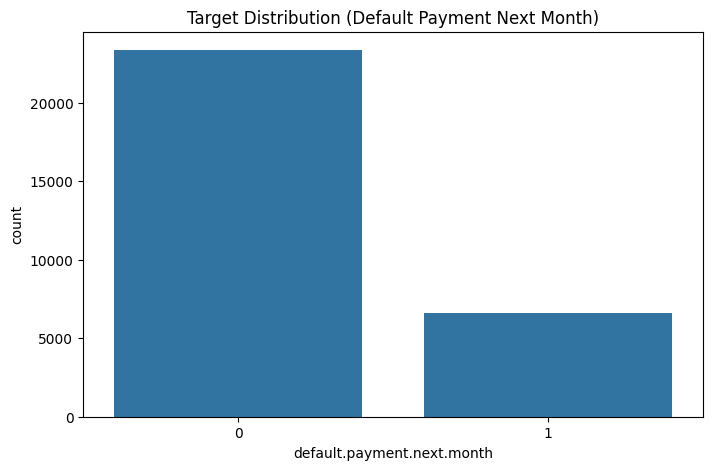

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x="default.payment.next.month", data=df)
plt.title("Target Distribution (Default Payment Next Month)")
plt.show()

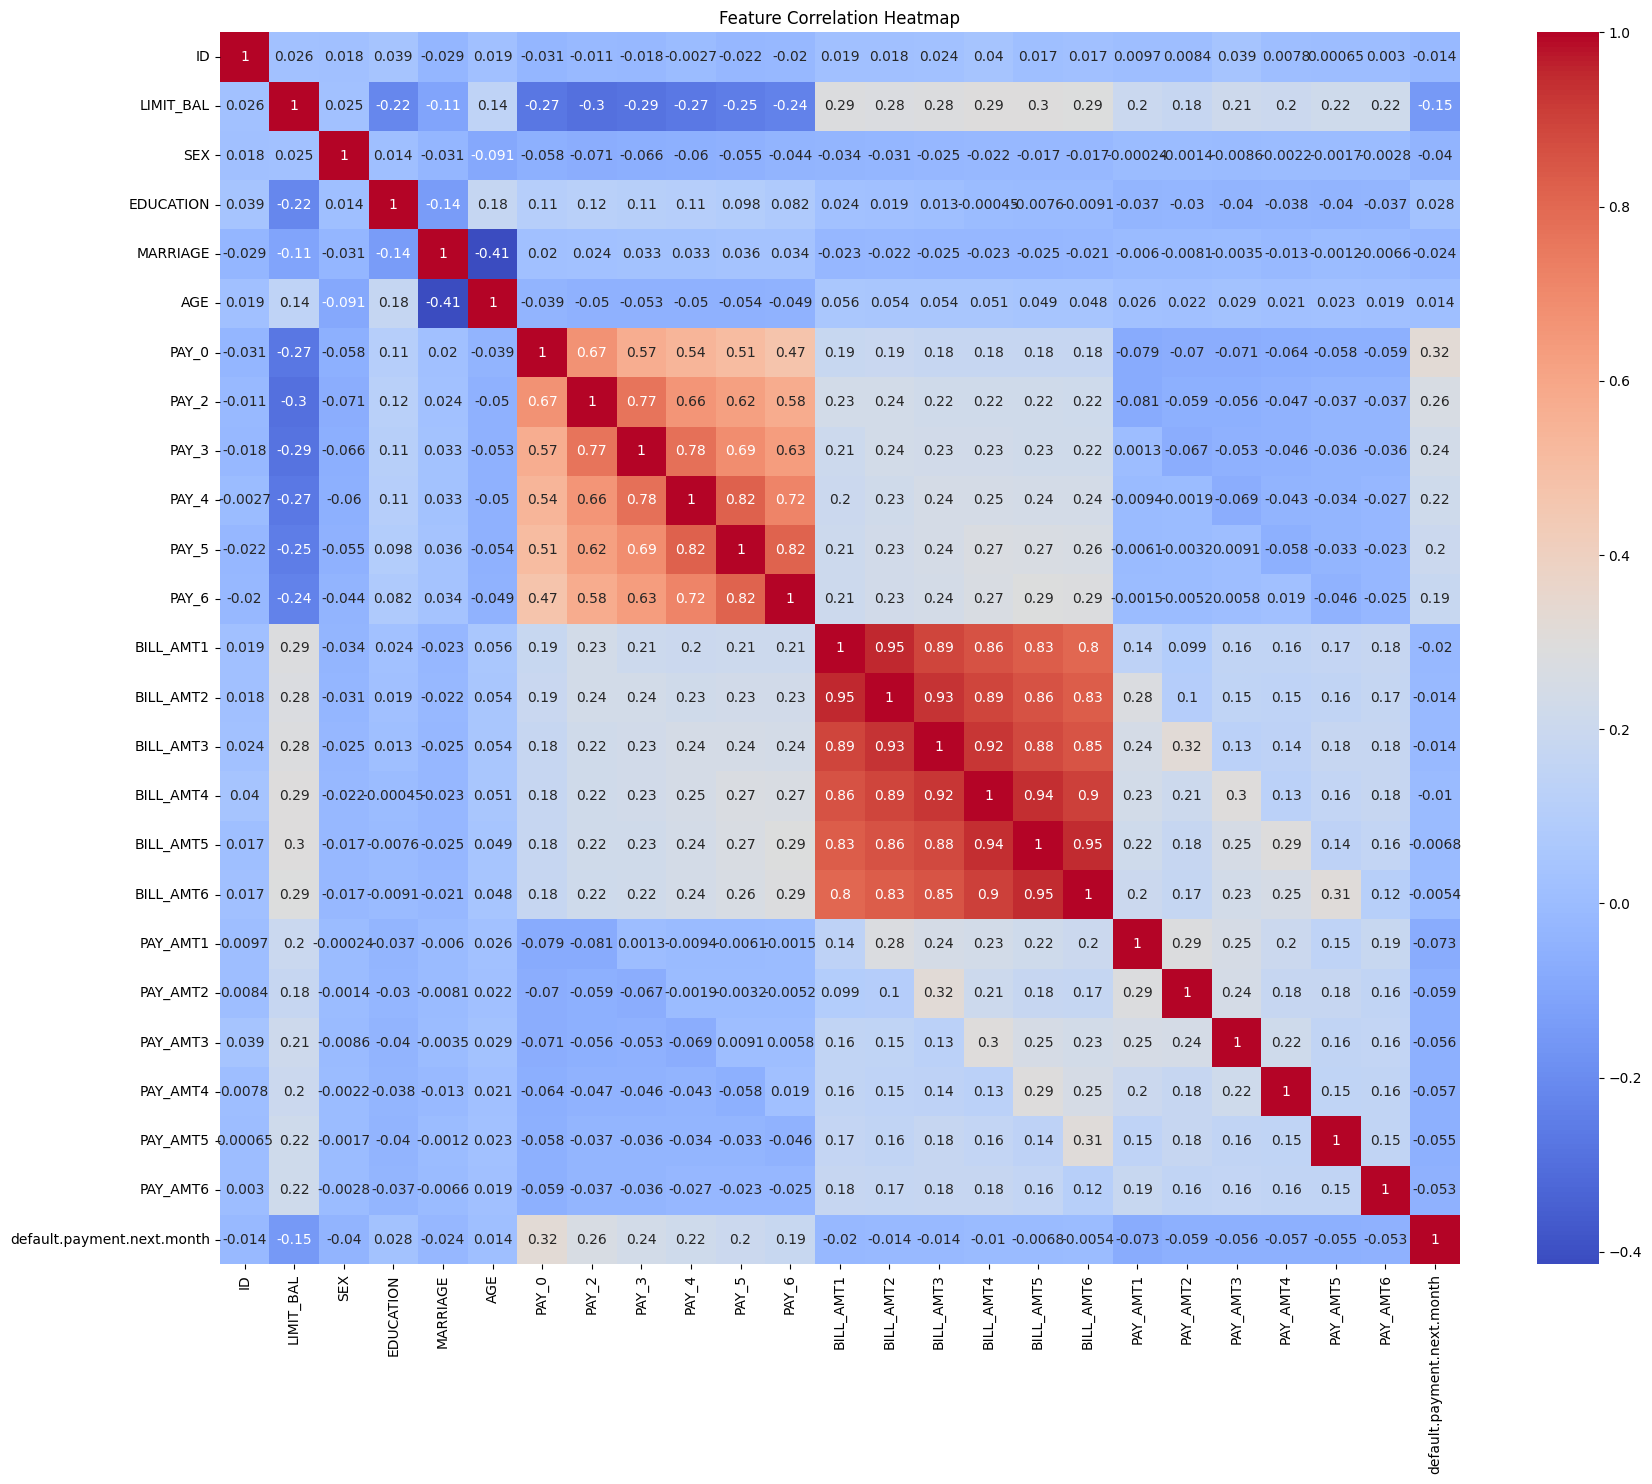

In [10]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------
# Train-Test Split
# -------------------------------

In [11]:
X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]

# Apply SMOTE + ENN

In [12]:
smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X, y)

print("Before:", Counter(y))
print("After:", Counter(y_resampled))

Before: Counter({0: 23364, 1: 6636})
After: Counter({1: 17396, 0: 10058})


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# Dwarf Mongoose Optimization Algorithm (DMOA)
# -------------------------------

In [14]:

def fitness_function(features, X_train, X_test, y_train, y_test):
    """Evaluate selected features using RandomForest accuracy."""
    selected = [i for i in range(len(features)) if features[i] == 1]
    if len(selected) == 0:
        return 0
    
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    clf.fit(X_train[:, selected], y_train)
    y_pred = clf.predict(X_test[:, selected])
    return accuracy_score(y_test, y_pred)

def dwarf_mongoose(X_train, X_test, y_train, y_test, n_agents=10, max_iter=20):
    n_features = X_train.shape[1]
    population = np.random.randint(0, 2, (n_agents, n_features))  # binary feature selection
    fitness = np.array([fitness_function(ind, X_train, X_test, y_train, y_test) for ind in population])
    
    best_idx = np.argmax(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    convergence_curve = []
    
    for it in range(max_iter):
        for i in range(n_agents):
            rand_idx = np.random.randint(0, n_agents)
            if fitness[rand_idx] > fitness[i]:
                # update rule (mimicking mongoose exploration)
                diff = population[rand_idx] ^ population[i]
                population[i] = population[i] ^ diff
        
        fitness = np.array([fitness_function(ind, X_train, X_test, y_train, y_test) for ind in population])
        current_best_idx = np.argmax(fitness)
        
        if fitness[current_best_idx] > best_fitness:
            best_solution = population[current_best_idx].copy()
            best_fitness = fitness[current_best_idx]
        
        convergence_curve.append(best_fitness)
        print(f"Iteration {it+1}/{max_iter} | Best Accuracy: {best_fitness:.4f}")
    
    return best_solution, best_fitness, convergence_curve

In [17]:
# Run optimization
best_features, best_acc, curve = dwarf_mongoose(X_train, X_test, y_train, y_test, n_agents=15, max_iter=30)
selected_idx = [i for i in range(len(best_features)) if best_features[i] == 1]

Iteration 1/30 | Best Accuracy: 0.8170
Iteration 2/30 | Best Accuracy: 0.8170
Iteration 3/30 | Best Accuracy: 0.8170
Iteration 4/30 | Best Accuracy: 0.8170
Iteration 5/30 | Best Accuracy: 0.8170
Iteration 6/30 | Best Accuracy: 0.8170
Iteration 7/30 | Best Accuracy: 0.8170
Iteration 8/30 | Best Accuracy: 0.8170
Iteration 9/30 | Best Accuracy: 0.8170
Iteration 10/30 | Best Accuracy: 0.8170
Iteration 11/30 | Best Accuracy: 0.8170
Iteration 12/30 | Best Accuracy: 0.8170
Iteration 13/30 | Best Accuracy: 0.8170
Iteration 14/30 | Best Accuracy: 0.8170
Iteration 15/30 | Best Accuracy: 0.8170
Iteration 16/30 | Best Accuracy: 0.8170
Iteration 17/30 | Best Accuracy: 0.8170
Iteration 18/30 | Best Accuracy: 0.8170
Iteration 19/30 | Best Accuracy: 0.8170
Iteration 20/30 | Best Accuracy: 0.8170
Iteration 21/30 | Best Accuracy: 0.8170
Iteration 22/30 | Best Accuracy: 0.8170
Iteration 23/30 | Best Accuracy: 0.8170
Iteration 24/30 | Best Accuracy: 0.8170
Iteration 25/30 | Best Accuracy: 0.8170
Iteration

# Selected Features

In [40]:
selected_features = X.columns[selected_idx]
selected_features

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_3', 'PAY_4', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT5',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5'],
      dtype='object')

In [18]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train[:, selected_idx], y_train)
y_pred = clf.predict(X_test[:, selected_idx])

# === Jaya Algorithm ===

In [20]:
# === Jaya Algorithm ===
def jaya_hyperparams(population_size=10, iterations=5):
    param_bounds = {
        'learning_rate': (0.0001, 0.01),
        'gru_units': (32, 128),
        'batch_size': (16, 64),
        'epochs': (10, 50)
    }

    def random_solution():
        return {
            'learning_rate': np.random.uniform(*param_bounds['learning_rate']),
            'gru_units': int(np.random.uniform(*param_bounds['gru_units'])),
            'batch_size': int(np.random.uniform(*param_bounds['batch_size'])),
            'epochs': int(np.random.uniform(*param_bounds['epochs']))
        }

    def fitness(solution, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        model = build_rxt_gru((X_train.shape[1], 1), solution['gru_units'])
        model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=solution['learning_rate']), metrics=['accuracy'])
        model.fit(X_train_rnn, y_train, epochs=solution['epochs'], batch_size=solution['batch_size'], verbose=0)
        _, acc = model.evaluate(X_test_rnn, y_test, verbose=0)
        return acc

    population = [random_solution() for _ in range(population_size)]
    best = max(population, key=lambda sol: fitness(sol, jaya_X, jaya_y))
    worst = min(population, key=lambda sol: fitness(sol, jaya_X, jaya_y))

    for _ in range(iterations):
        new_population = []
        for sol in population:
            new_sol = {}
            for key in sol:
                r1, r2 = random.random(), random.random()
                new_val = sol[key] + r1 * (best[key] - abs(sol[key])) - r2 * (worst[key] - abs(sol[key]))
                low, high = param_bounds[key]
                new_val = max(low, min(high, new_val))
                new_sol[key] = int(new_val) if 'int' in str(type(param_bounds[key][0])) else new_val
            new_population.append(new_sol)
        population = new_population
        best = max(population, key=lambda sol: fitness(sol, jaya_X, jaya_y))
        worst = min(population, key=lambda sol: fitness(sol, jaya_X, jaya_y))

    return best

# === RXT-GRU Model Builder ===

In [21]:
def build_rxt_gru(input_shape, gru_units):
    inputs = Input(shape=input_shape)
    convs = [Conv1D(32, kernel_size=3, padding='same', activation='relu')(inputs) for _ in range(4)]
    x = Add()(convs)
    x = GRU(gru_units, return_sequences=True)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(1, activation='sigmoid')(x)
    return Model(inputs, x)

# These global placeholders are required for Jaya's fitness function.
jaya_X, jaya_y = None, None

In [22]:
def build_resnet_model(input_shape):
    inp = Input(shape=input_shape)
    x = Dense(64, activation='relu')(inp)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    shortcut = Dense(64)(inp)
    x = Add()([x, shortcut])
    x = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out)

# === AdaBoost ===

In [23]:
ada = AdaBoostClassifier(n_estimators=50)
ada.fit(X_train, y_train)
ada_preds = ada.predict(X_test)
ada_acc = accuracy_score(y_test, ada_preds) * 100

In [36]:
print("================== classification report ADABoost ==============================")
print(f"accuracy: {svm_acc}")
print(classification_report(y_test, ada_preds, digits=4))

================== classification report ADABoost ==============================
accuracy: 81.46666666666667
              precision    recall  f1-score   support

           0     0.8332    0.9566    0.8907      7009
           1     0.6810    0.3260    0.4409      1991

    accuracy                         0.8171      9000
   macro avg     0.7571    0.6413    0.6658      9000
weighted avg     0.7996    0.8171    0.7912      9000



# === SVM ===

In [24]:
svm = SVC(kernel='rbf', gamma='scale')
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds) * 100

In [34]:
print("================== classification report SVM ==============================")
print(f"accuracy: {svm_acc}")
print(classification_report(y_test, svm_preds, digits=4))

================== classification report SVM ==============================
accuracy: 81.46666666666667
              precision    recall  f1-score   support

           0     0.8333    0.9526    0.8890      7009
           1     0.6636    0.3290    0.4399      1991

    accuracy                         0.8147      9000
   macro avg     0.7484    0.6408    0.6644      9000
weighted avg     0.7957    0.8147    0.7896      9000



In [25]:
jaya_X, jaya_y = X_train, y_train
# === RXT-GRU with Jaya ===
params = jaya_hyperparams()
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

rxt_gru = build_rxt_gru((X_train.shape[1], 1), params['gru_units'])

In [26]:
rxt_gru.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=params['learning_rate']), metrics=['accuracy'])
rxt_gru.fit(X_train_rnn, y_train, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
_, rxt_acc = rxt_gru.evaluate(X_test_rnn, y_test, verbose=0)

In [33]:
print(rxt_gru)

<Functional name=functional_120, built=True>


In [39]:
# Get predictions
y_pred_prob = rxt_gru.predict(X_test_rnn)

# Convert probabilities to binary (0/1)
y_pred = (y_pred_prob > 0.5).astype("int32")

print("================== classification report rxt ==============================")
print(f"accuracy: {rxt_acc}")

# Generate classification report
print(classification_report(y_test, y_pred, digits=4))

282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
================== classification report rxt ==============================
accuracy: 0.8153333067893982
              precision    recall  f1-score   support

           0     0.8406    0.9414    0.8881      7009
           1     0.6429    0.3717    0.4710      1991

    accuracy                         0.8153      9000
   macro avg     0.7418    0.6565    0.6796      9000
weighted avg     0.7969    0.8153    0.7959      9000



In [28]:
# === ResNet ===
resnet_model = build_resnet_model((X_train.shape[1],))
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
resnet_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
preds_resnet = resnet_model.predict(X_test)
preds_resnet_label = (preds_resnet > 0.5).astype(int)
resnet_acc = accuracy_score(y_test, preds_resnet_label) * 100

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   


In [32]:
print("================== classification report resnet ==============================")
print(f"accuracy: {resnet_acc}")
print(classification_report(y_test, preds_resnet_label, digits=4))

================== classification report resnet ==============================
accuracy: 81.37777777777778
              precision    recall  f1-score   support

           0     0.8425    0.9358    0.8867      7009
           1     0.6296    0.3842    0.4772      1991

    accuracy                         0.8138      9000
   macro avg     0.7361    0.6600    0.6820      9000
weighted avg     0.7954    0.8138    0.7961      9000

